# HW7: Fine-tuning BERT на датасете AG News

В этом ноутбуке мы берём предобученную модель `bert-base-uncased` и дообучаем её на задаче **мультиклассовой классификации новостей**.

Выбранная задача:
- вход: текст новости;
- выход: один из 4 классов: `World`, `Sports`, `Business`, `Sci/Tech`.

Выбранный датасет:
- `ag_news` из библиотеки Hugging Face Datasets;
- в исходном датасете 120000 обучающих и 7600 тестовых примеров.

In [1]:
# # Установка библиотек
# !pip -q install -U transformers datasets evaluate accelerate scikit-learn matplotlib seaborn pandas

In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from IPython.display import display
from datasets import DatasetDict, load_dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

MODEL_CHECKPOINT = "bert-base-uncased"
DATASET_NAME = "ag_news"
MAX_LENGTH = 512
TRAIN_SAMPLES = 12000
VAL_SAMPLES = 2000 if torch.cuda.is_available() else 500
TEST_SAMPLES = 2000 if torch.cuda.is_available() else 500
NUM_EPOCHS = 10
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
# HF_TOKEN=

label_names = ["World", "Sports", "Business", "Sci/Tech"]
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

/home/artem216/hw_spring_semestr_2026/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER


## 1. Загружаем датасет и смотрим примеры


In [3]:
raw_datasets = load_dataset(DATASET_NAME)
print(raw_datasets)

for i in range(3):
    sample = raw_datasets["train"][i]
    print(f"[{i}] label={sample['label']} ({id2label[sample['label']]})")
    print(sample["text"][:300])
    print()

train_valid = raw_datasets["train"].train_test_split(
    test_size=0.1,
    seed=SEED,
    stratify_by_column="label",
)

dataset_splits = DatasetDict({
    "train": train_valid["train"],
    "validation": train_valid["test"],
    "test": raw_datasets["test"],
})

print(dataset_splits)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
[0] label=2 (Business)
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

[1] label=2 (Business)
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

[2] label=2 (Business)
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows:

## 2. Токенизация


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def preprocess_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = dataset_splits.map(
    preprocess_function,
    batched=True,
    remove_columns=["text"],
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_datasets)

Map: 100%|██████████| 7600/7600 [00:00<00:00, 12017.68 examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


## 3. Загружаем предобученный BERT и определяем метрики


In [5]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="macro",
    )["f1"]

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2034.40it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 4. Fine-tuning


In [6]:
output_dir = "./ag-news-bert-finetuned"

training_kwargs = dict(
    output_dir=output_dir,
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    eval_strategy="epoch",
)

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

trainer = Trainer(**trainer_kwargs)

start_time = time.perf_counter()
trainer.train()
training_time_sec = time.perf_counter() - start_time

print(f"Обучение завершено за {training_time_sec / 60:.2f} минут")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.200210,0.224759,0.934500,0.934734
2,0.168374,0.197626,0.945250,0.945254
3,0.134409,0.236681,0.940667,0.940719
4,0.059424,0.272981,0.942833,0.942921


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


KeyboardInterrupt: 

## 5. Оценка качества на test

In [7]:
test_metrics = trainer.predict(tokenized_datasets["test"], metric_key_prefix="test")

display(test_metrics.metrics)

{'test_loss': 0.30278337001800537,
 'test_accuracy': 0.9415789473684211,
 'test_macro_f1': 0.9415764427061324,
 'test_runtime': 5.0191,
 'test_samples_per_second': 1514.226,
 'test_steps_per_second': 47.419}

## 6. Логи обучения и графики

По аналогии с исходным ноутбуком строим графики train/eval loss и следим за качеством на валидации.

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
575,28600,4.237037,0.089130,0.076564,0.000013
576,28650,4.244444,0.048631,0.069097,0.000013
577,28700,4.251852,0.033704,0.369707,0.000013
578,28750,4.259259,0.058934,0.027399,0.000013
579,28800,4.266667,0.049363,0.311151,0.000013
580,28850,4.274074,0.019197,0.005999,0.000013
581,28900,4.281481,0.037477,0.013220,0.000013
582,28950,4.288889,0.060590,3.358124,0.000013
583,29000,4.296296,0.032482,0.509115,0.000013
584,29050,4.303704,0.090268,0.032425,0.000013



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_macro_f1
135,6750,1.0,0.224759,0.934500,0.934734
271,13500,2.0,0.197626,0.945250,0.945254
407,20250,3.0,0.236681,0.940667,0.940719
543,27000,4.0,0.272981,0.942833,0.942921


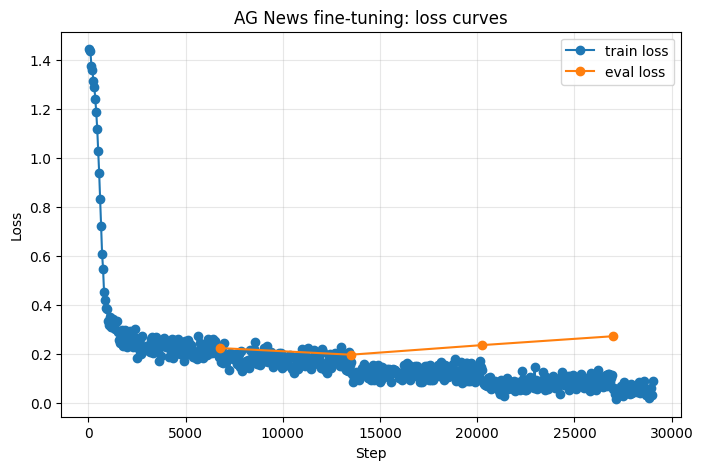

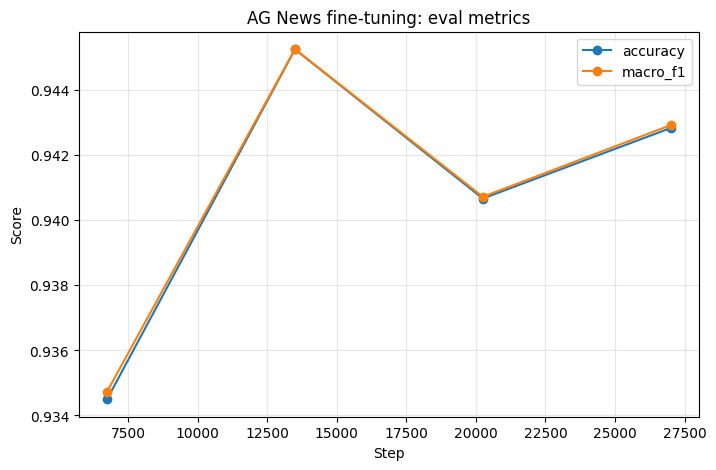

In [8]:
log_df = pd.DataFrame(trainer.state.log_history)
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    display(train_logs[[c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    display(eval_logs[[c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_macro_f1"] if c in eval_logs.columns]].tail(10))
else:
    print("Нет eval-логов")

plt.figure(figsize=(8, 5))
if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")
if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AG News fine-tuning: loss curves")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

metric_columns = [c for c in ["eval_accuracy", "eval_macro_f1"] if c in eval_logs.columns]
if len(eval_logs) > 0 and metric_columns:
    plt.figure(figsize=(8, 5))
    for col in metric_columns:
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("AG News fine-tuning: eval metrics")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

## 7. Матрица ошибок и classification report

Теперь посмотрим, какие классы модель путает чаще всего.

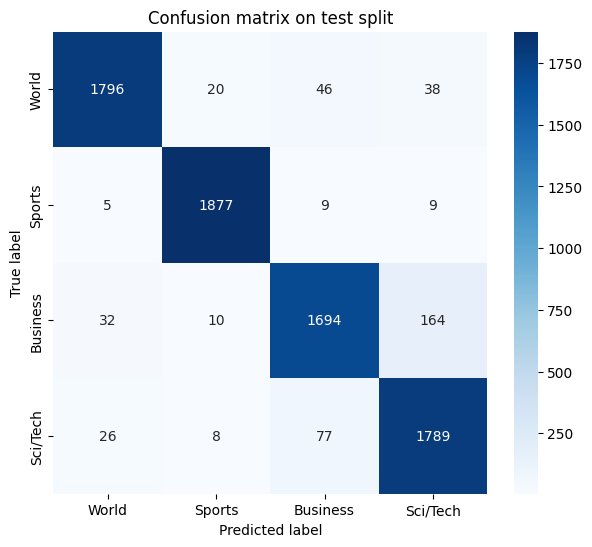

              precision    recall  f1-score   support

       World     0.9661    0.9453    0.9556      1900
      Sports     0.9802    0.9879    0.9840      1900
    Business     0.9277    0.8916    0.9093      1900
    Sci/Tech     0.8945    0.9416    0.9174      1900

    accuracy                         0.9416      7600
   macro avg     0.9421    0.9416    0.9416      7600
weighted avg     0.9421    0.9416    0.9416      7600



In [9]:
test_predictions = trainer.predict(tokenized_datasets["test"])
y_true = np.array(dataset_splits["test"]["label"])
y_pred = np.argmax(test_predictions.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix on test split")
plt.show()

print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

## 8. Примеры предсказаний модели

In [10]:
sample_texts = [
    "NASA announced a new mission to study Mars and test advanced landing systems.",
    "The stock market rallied after the company reported stronger quarterly earnings.",
    "The team secured a dramatic win in overtime after a late equalizer.",
    "Diplomats met to discuss the latest developments in the regional conflict.",
]

inputs = tokenizer(sample_texts, truncation=True, padding=True, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model(**inputs)
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()

for text, pred in zip(sample_texts, preds):
    print(f"TEXT: {text}")
    print(f"PREDICTED LABEL: {id2label[int(pred)]}")
    print()

TEXT: NASA announced a new mission to study Mars and test advanced landing systems.
PREDICTED LABEL: Sci/Tech

TEXT: The stock market rallied after the company reported stronger quarterly earnings.
PREDICTED LABEL: Business

TEXT: The team secured a dramatic win in overtime after a late equalizer.
PREDICTED LABEL: Sports

TEXT: Diplomats met to discuss the latest developments in the regional conflict.
PREDICTED LABEL: World

